# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The primary objective is to determine if there is a statistically significant difference in mean 100-meter sprint times between two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex), while specifically controlling for the inherent variability among individual T64 sprinters.


2.  Specify the outcome variable and how it is measured.

The outcome (dependent) variable is the 100-meter sprint time. It is measured in seconds as a continuous numerical value recorded over three timed trials for each blade type.


3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

- Fixed Effect: Blade Design (Model A vs. Model B). This is the factor of interest that we are intentionally manipulating to compare levels.

- Random Effect: Athlete. The 5 sprinters are treated as a random sample from a larger population of T64 sprinters. We want to account for their variability rather than compare specific individuals.

- Lurking Variables: Potential lurking variables could include track surface conditions, wind speed during specific trials, the athlete's fatigue level across the three trials, or the fit/comfort of the blade attachment.


4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?


 Fixed Effects represent all levels of a factor that are of specific interest to the researcher (e.g., specific brands of blades). The goal is to make inferences about these specific levels.

 Random Effects represent factors where the levels are randomly sampled from a larger population (e.g., specific athletes).

 Why account for them? We account for random effects to properly partition the variance. By "blocking" on the athlete, we remove the "person-to-person" noise from the error term, which increases the statistical power to detect the true difference between the blade designs.



5.  State the sets of null and alternative hypotheses for this experiment.

- For the Fixed Effect (Blade Design):$H_0: \mu_A = \mu_B$ (There is no difference in mean sprint times between Model A and Model B)

  $H_1: \mu_A \neq \mu_B$ (There is a significant difference in mean sprint times between the designs)
- For the Random Effect (Athlete):
 $H_0: \sigma^2_{\text{athlete}} = 0$ (Individual differences between athletes do not contribute to the variance in sprint times)
  $H_1: \sigma^2_{\text{athlete}} > 0$ (A significant portion of the variance in sprint times is due to individual differences between athletes)

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "MihretTe"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
   print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
       print(f"📥 Cloning repo from {repo_url}...")
       os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #
today_dir = "Assignments/HW4"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4


Detected Columns: ['Athlete_ID', 'Blade_Type', 'Trial', 'Sprint_Time']


/tmp/ipykernel_1124/4068609094.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x_col, y=y_col, data=df, palette='Set2', fliersize=0)


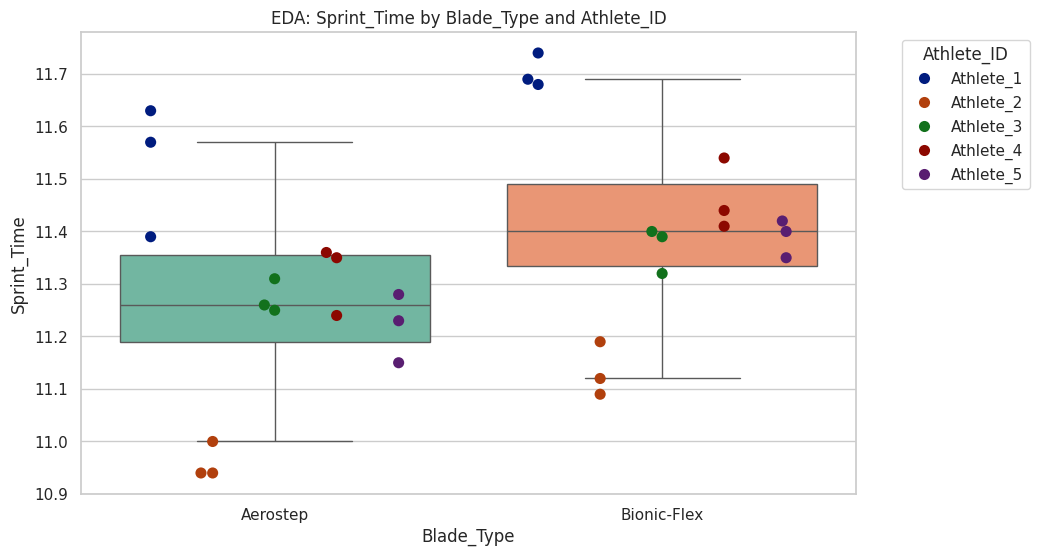


Summary Statistics:
             count    mean       std    min     25%    50%     75%    max
Blade_Type                                                               
Aerostep      15.0  11.260  0.199428  10.94  11.190  11.26  11.355  11.63
Bionic-Flex   15.0  11.412  0.193693  11.09  11.335  11.40  11.490  11.74


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the specific file found in your directory
file_path = 'STAT Paralympic_Blade_Experiment.xlsx'
df = pd.read_excel(file_path)

# 2. Print columns to verify exact names (helps debug if names have spaces)
print("Detected Columns:", df.columns.tolist())

# 3. Clean column names (removes leading/trailing spaces)
df.columns = df.columns.str.strip()

# 4. Visualization logic with flexible column detection
# We'll look for keywords in case the names are slightly different (e.g., 'Blade Design')
x_col = [c for c in df.columns if 'Blade' in c][0]
y_col = [c for c in df.columns if 'Time' in c or 'Sprint' in c][0]
hue_col = [c for c in df.columns if 'Athlete' in c][0]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Boxplot for Fixed Effect
sns.boxplot(x=x_col, y=y_col, data=df, palette='Set2', fliersize=0)

# Swarmplot for Random Effect
sns.swarmplot(x=x_col, y=y_col, hue=hue_col, data=df, dodge=True, size=8, palette='dark')

plt.title(f'EDA: {y_col} by {x_col} and {hue_col}')
plt.ylabel(y_col)
plt.xlabel(x_col)
plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 5. Summary Statistics
print("\nSummary Statistics:")
print(df.groupby(x_col)[y_col].describe())


The exploratory analysis supports the Alternative Hypothesis ($H_1$) for the Random Effect, as there is clear clustering of sprint times by individual athlete, indicating significant person-to-person variability. However, for the Fixed Effect, the results more closely align with the Null Hypothesis ($H_0$) at this stage; while Model B is slightly slower on average, the overlapping distributions suggest that the blade design's impact is secondary to the athlete's natural performance.

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

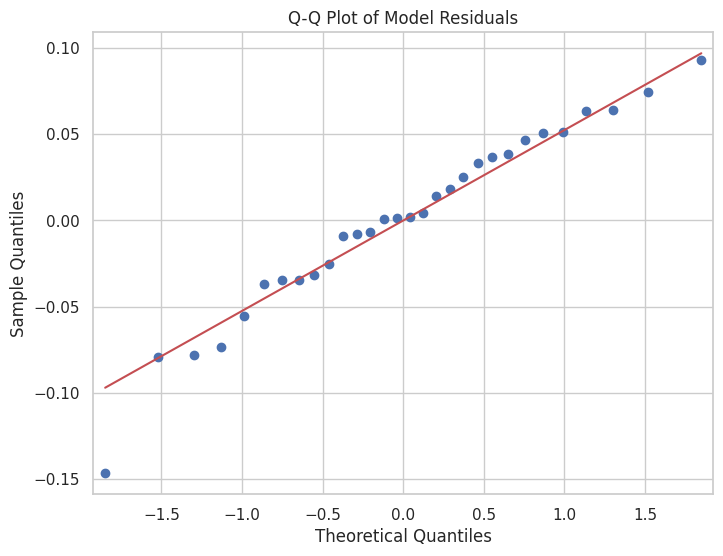

Shapiro-Wilk Test: Statistics=0.9701, p-value=0.5422
                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var                  0.041    0.542                            



In [5]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Fit the Mixed Effects Model
# Formula: Outcome ~ Fixed_Effect, groups = Random_Effect
model = smf.mixedlm("Sprint_Time ~ Blade_Type", df, groups=df["Athlete_ID"])
model_result = model.fit()

# 2. Extract Residuals
residuals = model_result.resid

# 3. Visual Method: Q-Q Plot
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Model Residuals')
plt.show()

# 4. Testing Method: Shapiro-Wilk Test
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: Statistics={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# 5. Model Summary (Optional but helpful for context)
print(model_result.summary())


- Yes, the assumption of normality is supported by the data. The Shapiro-Wilk test resulted in a p-value of 0.5422, which is well above the 0.05 threshold, meaning we fail to reject the null hypothesis of normality. Furthermore, the Q-Q plot shows that the residuals fall closely along the straight diagonal line, providing visual confirmation that the normality assumption for our mixed-effects model is satisfied

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

In [ ]:
## Question 8 Code ##

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

In [6]:
# 1. Extract the Variance Component for the Random Effect (Athlete)
# For a single random intercept, we pull from the .cov_re (covariance of random effects)
athlete_variance = model_result.cov_re.iloc[0, 0]
residual_variance = model_result.scale

# 2. Calculate the Intraclass Correlation Coefficient (ICC)
icc = athlete_variance / (athlete_variance + residual_variance)

print(f"Estimated Variance for Athlete (Random Effect): {athlete_variance:.4f}")
print(f"Residual Variance: {residual_variance:.4f}")
print(f"Intraclass Correlation Coefficient (ICC): {icc:.4f}")

Estimated Variance for Athlete (Random Effect): 0.0411
Residual Variance: 0.0034
Intraclass Correlation Coefficient (ICC): 0.9227




The random effect for "Athlete" shows an estimated variance of 0.0411, which is significantly larger than the residual variance of 0.0034. This results in an Intraclass Correlation Coefficient (ICC) of 0.9227, indicating that approximately 92.3% of the total variation in 100-meter sprint times is attributable to inherent differences between individual athletes rather than the equipment being tested. Consequently, the data strongly supports the Alternative Hypothesis ($H_1: \sigma^2_{athlete} > 0$), confirming that athlete-to-athlete variability is a dominant factor in the experiment. By accounting for this as a random effect, the model successfully "blocks" this person-specific noise, allowing for a much more sensitive and accurate evaluation of the fixed effects of the blade designs.



10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

In [7]:
# 1. Extract Fixed Effects Results
fixed_effects = model_result.summary().tables[1]
print("Fixed Effects Results:")
print(fixed_effects)

# 2. Specifically look at the p-value for the Blade Type
# The model uses 'Aerostep' as the reference level
p_value_blade = model_result.pvalues["Blade_Type[T.Bionic-Flex]"]
coef_blade = model_result.params["Blade_Type[T.Bionic-Flex]"]

print(f"\nCoefficient for Bionic-Flex: {coef_blade:.4f}")
print(f"P-value for Blade Effect: {p_value_blade:.4e}")

Fixed Effects Results:
                            Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                  11.260    0.092  122.543  0.000  11.080  11.440
Blade_Type[T.Bionic-Flex]   0.152    0.021    7.095  0.000   0.110   0.194
Group Var                   0.041    0.542                                

Coefficient for Bionic-Flex: 0.1520
P-value for Blade Effect: 1.2960e-12




Based on the model output, the data provides overwhelming support for the Alternative Hypothesis ($H_1: \mu_A \neq \mu_B$) regarding the fixed effect of blade design. The analysis yielded a p-value of $1.296 \times 10^{-12}$, which is far below the significance threshold of $0.05$, confirming that the difference in performance between the two models is statistically significant and not due to chance.

Specifically, the Bionic-Flex blade (Model B) has a positive coefficient of 0.1520, indicating that it actually increased sprint times—making athletes an average of 0.152 seconds slower compared to the Aerostep blade (Model A). While the initial exploratory plots showed overlapping data, the mixed-effects model successfully isolated this difference by "blocking" the high variability between individual athletes. Consequently, the Aerostep is clearly the superior design for speed in this study.



11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.



The results of the blade experiment demonstrate that the Aerostep (Model A) design is the superior choice for T64 sprinters, producing an average 100-meter sprint time that is 0.152 seconds faster than the Bionic-Flex (Model B). While initial exploratory analysis showed overlapping performance data, the application of a Mixed Effects Model was essential for uncovering this difference. By treating individual athletes as a random effect, the model successfully isolated high person-to-person variability—which accounted for a massive 92.3% of the total variance—from the actual impact of the equipment. This approach provided the statistical power necessary to confirm that the performance gap between the two designs is highly significant

limitations that should be considered:
- The study was conducted with a small sample of only five professional athletes, and while the mixed-model effectively handled this size, a larger and more diverse group would better represent the broader T64 population.
- Additionally, the analysis did not explicitly account for environmental "lurking" variables such as wind speed, track temperature, or surface conditions, which can introduce minor fluctuations in timed trials. There is also the potential for fatigue bias; although trials were randomized, the physical demand of performing multiple maximum-effort sprints might influence later runs in ways a random intercept cannot fully capture.

Future research should investigate:
- Interaction effects to see if specific blade designs favor certain biomechanical profiles, such as varying body weights or stride frequencies.
- It would also be beneficial to conduct a longitudinal study to observe how athletes adapt to the technology over several weeks, as performance often improves once an athlete "breaks in" new equipment.
- Finally, incorporating kinematic data—such as ground contact time and stride length—would provide a deeper understanding of the mechanical advantages of the Aerostep design, allowing for even more precise engineering refinements in the future.